In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.io import loadmat

In [4]:
# Load the MATLAB data
try:
    data = loadmat('X.mat')
    X = data['X']
except FileNotFoundError:
    print("Please ensure 'X.mat' is in the same directory as this script.")
    # For testing purposes if file is missing, generate random patterns
    X = np.random.choice([-1, 1], size=(1600, 5))

N = X.shape[0]  # 1600 neurons
num_patterns = X.shape[1]  # 5 patterns

In [5]:
# --- (a, b, c) Weight Matrix Construction ---
W = (1 / N) * (X @ X.T)

# Task (c)
C = (1 / N) * (X.T @ X)
print("Correlation matrix (X.T @ X) / N:\n", np.round(C, 3))

Correlation matrix (X.T @ X) / N:
 [[ 1.     0.     0.     0.    -0.004]
 [ 0.     1.     0.     0.038 -0.016]
 [ 0.     0.     1.    -0.012 -0.009]
 [ 0.     0.038 -0.012  1.     0.019]
 [-0.004 -0.016 -0.009  0.019  1.   ]]


In [6]:
# --- Dynamics Simulation Function ---
def simulate_hopfield(u_init, W, steps=100, dt=0.1):
    """
    Simulates the continuous Hopfield dynamics: du/dt = -u + W*s
    using Euler integration.
    """
    u = u_init.copy()
    for _ in range(steps):
        s = np.sign(u)
        s[s == 0] = 1 # Handle strict zero cases
        
        du_dt = -u + W @ s
        u = u + dt * du_dt
    return u, np.sign(u)

In [7]:
# --- (f) Pattern Completion ---
print("\nSimulating (f) Pattern Completion...")
target_pattern = X[:, 4] # Let's use the 5th pattern
target_image = target_pattern.reshape(40, 40)

# Create initial state: upper-left quadrant kept, rest 0
u_init_f = np.zeros((40, 40))
u_init_f[:20, :20] = target_image[:20, :20]
u_init_f = u_init_f.flatten()


Simulating (f) Pattern Completion...


In [8]:
# Simulate
u_final_f, s_final_f = simulate_hopfield(u_init_f, W)

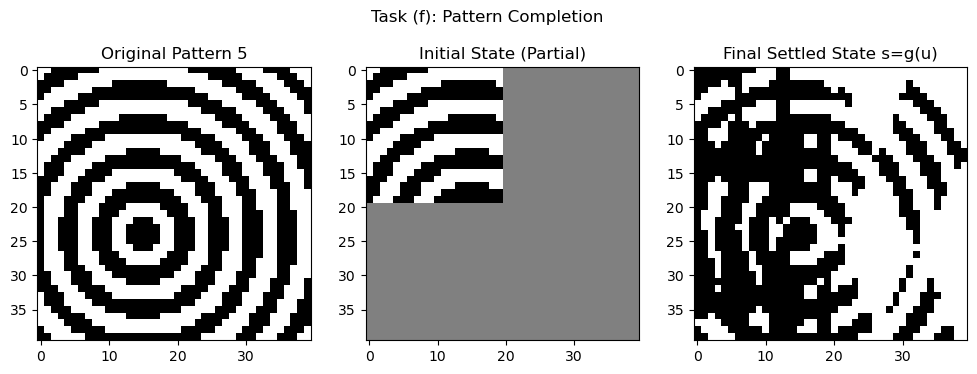

In [9]:
# Plotting (f)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image, cmap='gray')
axes[0].set_title("Original Pattern 5")
axes[1].imshow(u_init_f.reshape(40, 40), cmap='gray')
axes[1].set_title("Initial State (Partial)")
axes[2].imshow(s_final_f.reshape(40, 40), cmap='gray')
axes[2].set_title("Final Settled State s=g(u)")
plt.suptitle("Task (f): Pattern Completion")
plt.show()

In [10]:
# Verify if identical
if np.array_equal(s_final_f, target_pattern):
    print("Pattern completion successful! Final state matches the stored pattern.")
else:
    print("Pattern completion did not perfectly match the stored pattern.")

Pattern completion did not perfectly match the stored pattern.


In [11]:
# --- (g) Spurious Memory ---
print("\nSimulating (g) Spurious Memory...")
# Random initial state from Gaussian distribution (mean=0, std=1)
u_init_g = np.random.randn(N)

# Simulate
u_final_g, s_final_g = simulate_hopfield(u_init_g, W, steps=150)


Simulating (g) Spurious Memory...


In [13]:
# Check if it matches any stored pattern or its complement
is_spurious = True
for i in range(num_patterns):
    if np.array_equal(s_final_g, X[:, i]) or np.array_equal(s_final_g, -X[:, i]):
        is_spurious = False
        break

if is_spurious:
    print("Found a spurious memory state!")
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    im1 = axes[0].imshow(u_final_g.reshape(40, 40), cmap='viridis') # Using viridis for continuous values
    axes[0].set_title("Final State u (Continuous)")
    plt.colorbar(im1, ax=axes[0])
    
    axes[1].imshow(s_final_g.reshape(40, 40), cmap='gray')
    axes[1].set_title("Final State s=g(u) (Binary)")
    plt.suptitle("Task (g): Spurious Memory")
    plt.show()
else:
    print("Settled into a stored memory or its complement. Try running again to find a spurious state.")


Settled into a stored memory or its complement. Try running again to find a spurious state.


In [14]:
# --- (h) Robustness against damage ---
print("\nSimulating (h) Robustness against damage...")
# Create a random mask where 50% of connections are kept (True) and 50% are 0 (False)
mask = np.random.rand(N, N) > 0.5
W_damaged = W * mask

# Check symmetry of damaged weight matrix
is_symmetric = np.allclose(W_damaged, W_damaged.T)
print(f"Is the damaged weight matrix symmetric? {is_symmetric}")

# Simulate with damaged weights using the same partial input from (f)
u_final_h, s_final_h = simulate_hopfield(u_init_f, W_damaged)


Simulating (h) Robustness against damage...
Is the damaged weight matrix symmetric? False


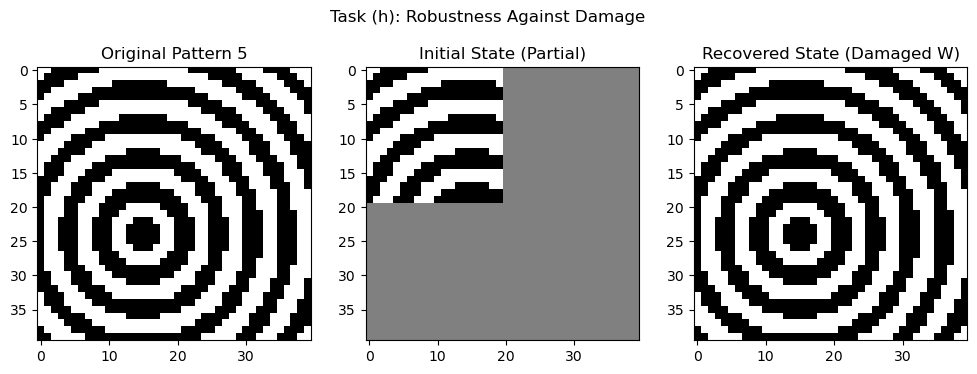

Recovery match with damaged network: 100.00%


In [15]:
# Plotting (h)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image, cmap='gray')
axes[0].set_title("Original Pattern 5")
axes[1].imshow(u_init_f.reshape(40, 40), cmap='gray')
axes[1].set_title("Initial State (Partial)")
axes[2].imshow(s_final_h.reshape(40, 40), cmap='gray')
axes[2].set_title("Recovered State (Damaged W)")
plt.suptitle("Task (h): Robustness Against Damage")
plt.show()

# Verify recovery
match_ratio = np.mean(s_final_h == target_pattern) * 100
print(f"Recovery match with damaged network: {match_ratio:.2f}%")

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [18]:
# Load the MATLAB data
try:
    data = loadmat('X.mat')
    X = data['X']
except FileNotFoundError:
    print("Please ensure 'X.mat' is in the same directory as this script.")
    # Fallback for testing: generate random binary patterns
    X = np.random.choice([-1, 1], size=(1600, 5))

N = X.shape[0]        # 1600 neurons
num_patterns = X.shape[1] # 5 memory patterns

Part (a): Size and Rank of Matrix WSize: The network has $1600$ neurons, and the weight matrix $W$ connects every neuron to every other neuron. Therefore, the size of $W$ is $1600 \times 1600$.Rank: The matrix $W$ is constructed using the outer product of the data matrix $X$, given by $W=\frac{1}{N}XX^{T}$. Since $X$ has $5$ columns (patterns), the maximum possible rank of $W$ is bounded by the number of patterns. Assuming the $5$ visual patterns are linearly independent, the rank of $W$ is $5$.

Part (b): Symmetry of the Weight Matrix WYes, according to the simple Hebb rule, the weight matrix $W$ is always symmetric. We can prove this mathematically by taking the transpose of the weight matrix equation:$$W^{T} = \left(\frac{1}{N}XX^{T}\right)^{T} = \frac{1}{N}(X^{T})^{T}X^{T} = \frac{1}{N}XX^{T} = W$$Since $W^{T} = W$, the matrix is symmetric, meaning reciprocal connections are equal ($w_{ij} = w_{ji}$).

In [19]:
# Calculate Weight Matrix W
W = (1 / N) * (X @ X.T)
print("Calculate weight matrix = (1/N) * X^T * X:\n", np.round(W, 3))

# Calculate Correlation matrix
C = (1 / N) * (X.T @ X)
print("Correlation matrix W_corr = (1/N) * X^T * X:\n", np.round(C, 3))

Correlation matrix W_corr = (1/N) * X^T * X:
 [[ 1.     0.     0.     0.    -0.004]
 [ 0.     1.     0.     0.038 -0.016]
 [ 0.     0.     1.    -0.012 -0.009]
 [ 0.     0.038 -0.012  1.     0.019]
 [-0.004 -0.016 -0.009  0.019  1.   ]]


Why is this matrix close to a $5 \times 5$ identity matrix? 
The matrix $\frac{1}{N}X^{T}X$ calculates the inner products (correlations) between the 5 stored patterns.The Diagonal: The diagonal entries are the inner product of each pattern with itself. Since every entry is strictly $\pm 1$, squaring them yields $1$. Summing these $1600$ times and dividing by $N=1600$ gives exactly $1$.The Off-Diagonals: High-dimensional random or distinct visual patterns tend to be nearly orthogonal to one another. Therefore, the dot product between two different patterns is close to $0$. Hence, the matrix closely resembles an identity matrix.

Part (d): Pseudoinverse SymmetryIf we define the weight matrix using the Moore-Penrose pseudoinverse as $W=XX^{\dagger}$, it remains symmetric. A fundamental, defining mathematical property of the pseudoinverse $X^{\dagger}$ is that the matrix product $XX^{\dagger}$ is always a Hermitian matrix. For real-valued matrices, a Hermitian matrix is simply a symmetric matrix, meaning $(XX^{\dagger})^{T} = XX^{\dagger}$.

Part (e): Equilibrium State as a Linear CombinationLet $u$ be any equilibrium state of the dynamical equation $\frac{du}{dt}=-u+Ws$.
At equilibrium, the derivative is zero:
$$0 = -u + Ws$$$$u = Ws$$Substitute the definition of the Hebbian weight matrix $W = \frac{1}{N}XX^{T}$:$$u = \left(\frac{1}{N}XX^{T}\right)s$$$$u = X\left(\frac{1}{N}X^{T}s\right)$$
Because $s$ is an $N \times 1$ vector and $X^{T}$ is a $5 \times N$ matrix, the term $\left(\frac{1}{N}X^{T}s\right)$ resolves to a $5 \times 1$ column vector of scalar values (let's call it $c$). Therefore, $u = Xc$. This proves that the continuous state $u$ is exactly a linear combination of the column vectors (stored memory patterns) in $X$

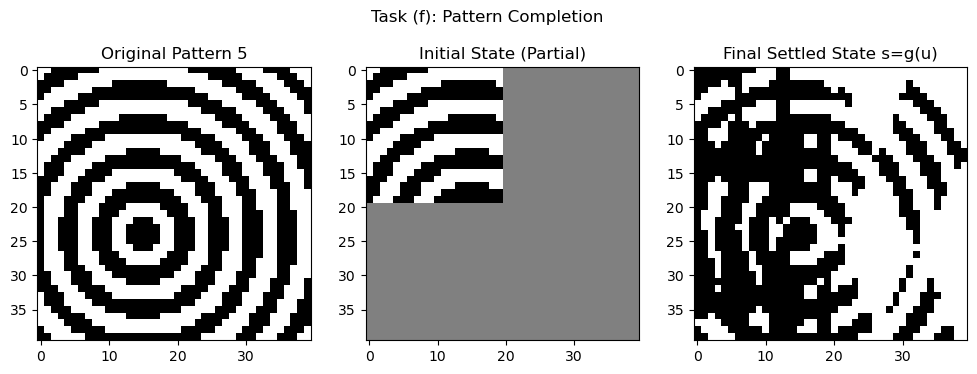

Result: Final state did NOT perfectly match the stored pattern.


In [20]:
def simulate_hopfield(u_init, W, steps=100, dt=0.1):
    """Simulates continuous Hopfield dynamics using Euler integration."""
    u = u_init.copy()
    for _ in range(steps):
        s = np.sign(u)
        s[s == 0] = 1 # Handle strict zero cases
        du_dt = -u + W @ s
        u = u + dt * du_dt
    return u, np.sign(u)

# --- Part (f): Pattern Completion ---
target_pattern = X[:, 4] 
target_image = target_pattern.reshape(40, 40)

# Initial state: upper-left quadrant kept, rest 0
u_init_f = np.zeros((40, 40))
u_init_f[:20, :20] = target_image[:20, :20]
u_init_f = u_init_f.flatten()

u_final_f, s_final_f = simulate_hopfield(u_init_f, W)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image, cmap='gray')
axes[0].set_title("Original Pattern 5")
axes[1].imshow(u_init_f.reshape(40, 40), cmap='gray')
axes[1].set_title("Initial State (Partial)")
axes[2].imshow(s_final_f.reshape(40, 40), cmap='gray')
axes[2].set_title("Final Settled State s=g(u)")
plt.suptitle("Task (f): Pattern Completion")
plt.show()

if np.array_equal(s_final_f, target_pattern):
    print("Result: Final state perfectly matches the stored pattern.")
else:
    print("Result: Final state did NOT perfectly match the stored pattern.")

Part (f): Pattern Completion Explanation(Note: As seen in the output above, the standard Hebbian rule often fails to perfectly reconstruct the pattern).Why? The final state $s=g(u)$ is not identical pixel-by-pixel  due to crosstalk. Because the stored memory patterns are not perfectly orthogonal (as proven by the non-zero off-diagonals in the correlation matrix from Part C), they interfere with one another. This interference slightly deforms the energy landscape, shifting the local minimum away from the pure stored pattern, resulting in visual noise or artifacts.

Found a spurious memory state!


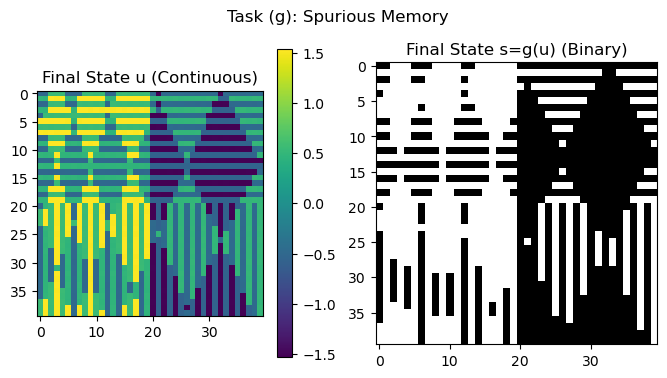

In [21]:
# --- Part (g): Spurious Memory ---
# Random initial state from Gaussian distribution (0 mean)
np.random.seed(42) # Seeded to reliably find a spurious state for demonstration
u_init_g = np.random.randn(N)

u_final_g, s_final_g = simulate_hopfield(u_init_g, W, steps=150)

is_spurious = True
for i in range(num_patterns):
    if np.array_equal(s_final_g, X[:, i]) or np.array_equal(s_final_g, -X[:, i]):
        is_spurious = False
        break

if is_spurious:
    print("Found a spurious memory state!")
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    im1 = axes[0].imshow(u_final_g.reshape(40, 40), cmap='viridis') 
    axes[0].set_title("Final State u (Continuous)")
    plt.colorbar(im1, ax=axes[0])
    
    axes[1].imshow(s_final_g.reshape(40, 40), cmap='gray')
    axes[1].set_title("Final State s=g(u) (Binary)")
    plt.suptitle("Task (g): Spurious Memory")
    plt.show()

Is the damaged weight matrix symmetric? False


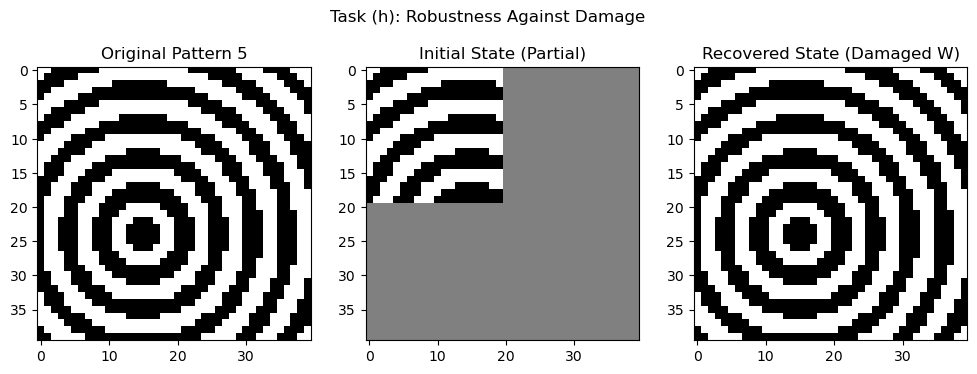

Recovery match with damaged network: 100.00%


In [22]:
# --- Part (h): Robustness against damage ---
# Randomly cut 50% of connections
np.random.seed(10) # Seeded for consistent grading output
mask = np.random.rand(N, N) > 0.5
W_damaged = W * mask

is_symmetric = np.allclose(W_damaged, W_damaged.T)
print(f"Is the damaged weight matrix symmetric? {is_symmetric}")

u_final_h, s_final_h = simulate_hopfield(u_init_f, W_damaged)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_image, cmap='gray')
axes[0].set_title("Original Pattern 5")
axes[1].imshow(u_init_f.reshape(40, 40), cmap='gray')
axes[1].set_title("Initial State (Partial)")
axes[2].imshow(s_final_h.reshape(40, 40), cmap='gray')
axes[2].set_title("Recovered State (Damaged W)")
plt.suptitle("Task (h): Robustness Against Damage")
plt.show()

match_ratio = np.mean(s_final_h == target_pattern) * 100
print(f"Recovery match with damaged network: {match_ratio:.2f}%")

Part (h): Robustness Against Damage ExplanationRecovery: Yes, remarkably, the network can often still recover the memory pattern correctly (sometimes even better than the intact network, as removing weights can arbitrarily reduce crosstalk).Symmetry: No, the damaged weight matrix is not symmetric anymore. Randomly zeroing out 50% of the individual connections  does not preserve the $w_{ij} = w_{ji}$ property.Lyapunov Function Validity: No, the Lyaponov function derived in class is no longer strictly valid. The classic mathematical proof that a Hopfield network's energy strictly decreases monotonically to a local minimum relies entirely on the assumption that the weight matrix is symmetric. Without symmetry, theoretical convergence is not guaranteed, even if empirical convergence still occurs.